## 📘 **Applications of Explainable AI in Predictive Modelling**  
---

🏫 Week 11   
📅 Date: 2025-05-07  
🧑‍🏫 Irena Zimovska

---




## **Load libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay


import joblib
from xgboost import XGBRegressor

import shap
from sklearn.inspection import permutation_importance
import dalex as dx
from lime.lime_tabular import LimeTabularExplainer




In [ ]:
# from alibi.explainers import ALE, plot_ale

## 🚀 **Final Model Exploration with XAI Techniques**

###  Useful Python Libraries

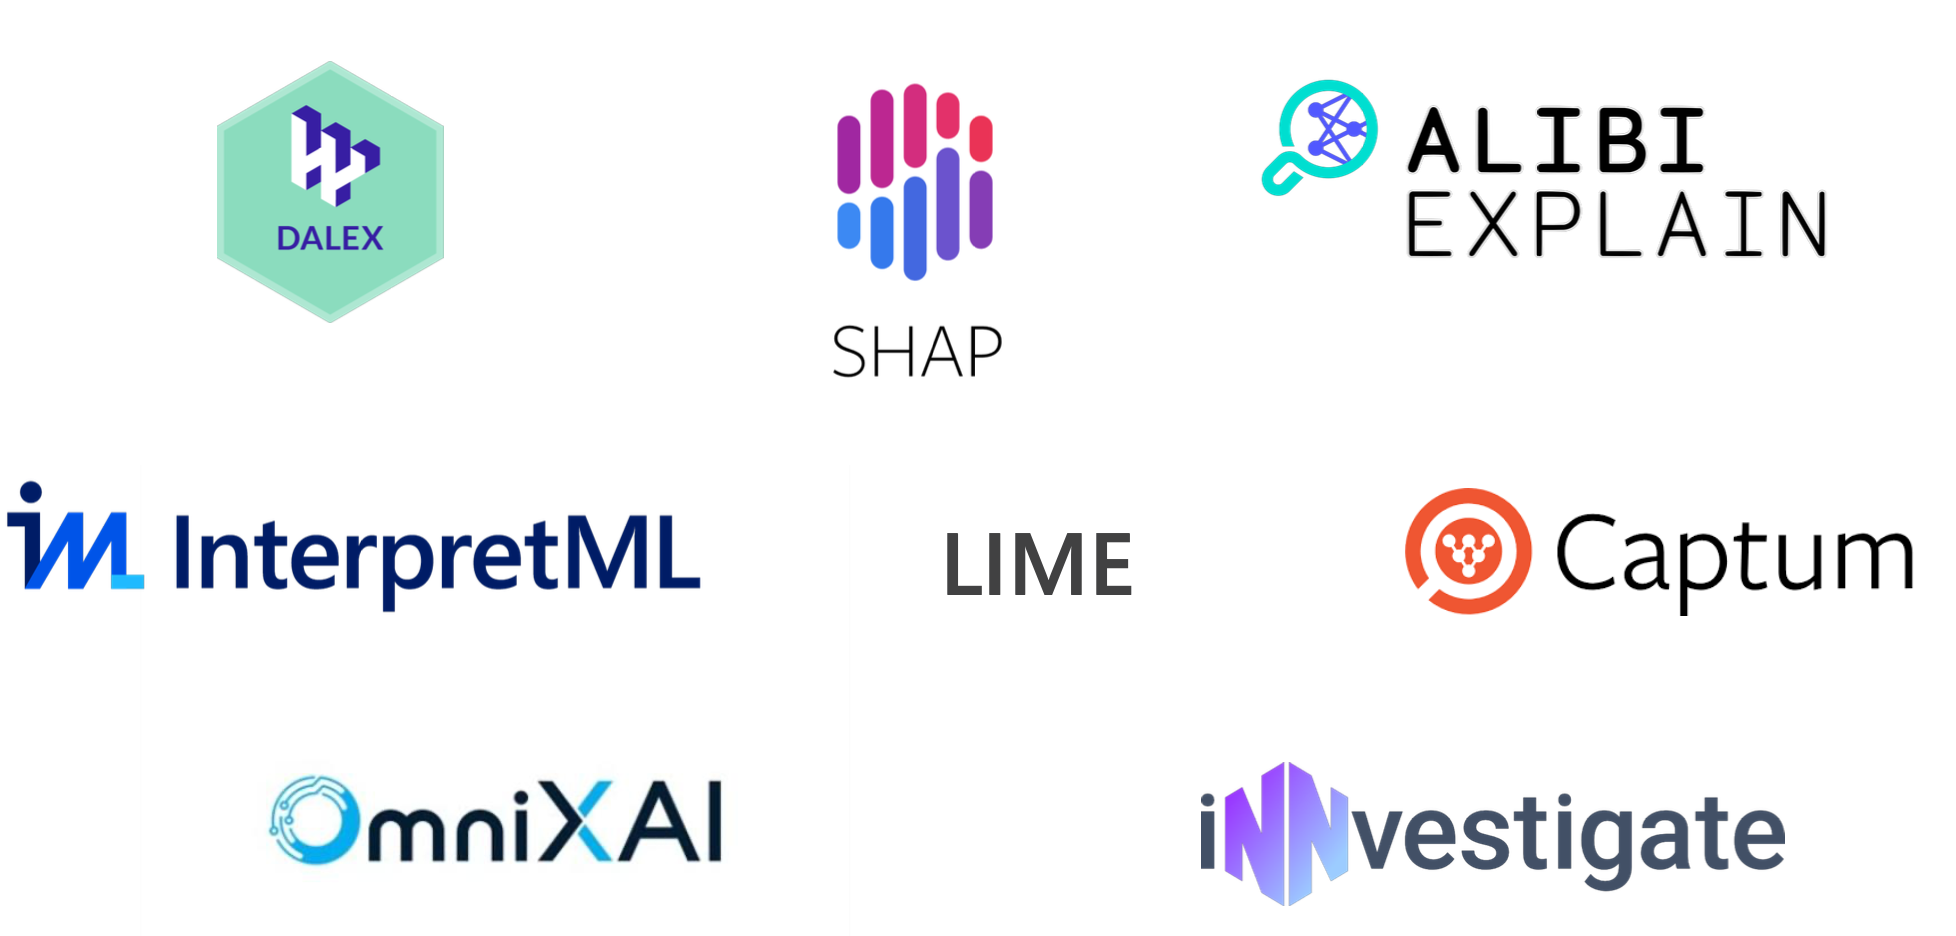

Below are recommended libraries to explore and interpret your final machine learning models — especially for tabular data:

---

- **[SHAP](https://shap.readthedocs.io/en/latest/)**  
  Unified framework based on Shapley values for both global and local explanations.

- **[DALEX](https://dalex.drwhy.ai/python/)**  
  Model-agnostic interpretability toolbox with PDPs, ICE, Break Down, and performance plots.

- **[InterpretML](https://interpret.ml/docs/index.html)**  
  Microsoft’s interpretable ML package supporting glass-box and black-box models with visual explanations.

- **[Alibi](https://github.com/SeldonIO/alibi)**  
  Advanced explainers including counterfactuals, anchors, and adversarial detectors.

- **[OmniXAI](https://github.com/salesforce/OmniXAI)**  
  All-in-one library for tabular, vision, and NLP XAI — backed by Salesforce Research.

- **[Eli5](https://eli5.readthedocs.io/en/latest/overview.html)**  
  Lightweight interpretability tools for linear models, tree ensembles, and permutation importance.

---


## **Load data**

In [2]:
# Load the prepared train and test data
X_train = pd.read_csv("../data/processed/X_train_data.csv")
X_test = pd.read_csv("../data/processed/X_test_data.csv")
y_train = pd.read_csv("../data/processed/y_train_data.csv")
y_test = pd.read_csv("../data/processed/y_test_data.csv")

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape :", X_test.shape, y_test.shape)


Train set shape: (15005, 21) (15005, 1)
Test set shape : (6431, 21) (6431, 1)


In [3]:
X_train["m2_ratio"] = X_train["m2_above"]/(X_train["m2_basement"]+0.1)
X_test["m2_ratio"] = X_test["m2_above"]/(X_test["m2_basement"]+0.1)

# Omitting zipcode 
X_train = X_train.drop(["zipcode", "m2_basement", "m2_above", "since_renovated"], axis=1)
X_test = X_test.drop(["zipcode", "m2_basement", "m2_above", "since_renovated"], axis=1)

## **Load the models**

In [4]:
import warnings
import joblib
import sklearn.compose._column_transformer as _ct
from sklearn.exceptions import InconsistentVersionWarning

model_files = {
    'LR Districts': '../models/linear_regression_pipeline.joblib',
    'DT Districts': '../models/decision_tree_pipeline.joblib',
    'RF Coords': '../models/random_forest_coords.joblib',
    'RF Districts': '../models/random_forest_district.joblib',
    'XGB Coords':   '../models/xgboost_coords.joblib',
    'XGB District': '../models/xgboost_district.joblib'
}

# ── Patch 1: restore missing _RemainderColsList for sklearn 1.7→1.8 ──
class _RemainderColsList(list):
    def __init__(self, lst, future_dtype=None):
        super().__init__(lst)
        self.future_dtype = future_dtype

_ct._RemainderColsList = _RemainderColsList

# ── Load ──
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InconsistentVersionWarning)
    models = {name: joblib.load(path) for name, path in model_files.items()}

# ── Patch 2: fix ColumnTransformer and XGBoost version mismatches ──
from sklearn.compose import ColumnTransformer

def patch_pipeline(pipeline):
    for _, step in pipeline.steps:
        # Fix sklearn force_int_remainder_cols
        if isinstance(step, ColumnTransformer):
            if getattr(step, 'force_int_remainder_cols', None) == 'deprecated':
                step.force_int_remainder_cols = False
        # Fix XGBoost missing feature_weights
        if hasattr(step, 'get_booster'):  # XGBModel duck-type check
            if not hasattr(step, 'feature_weights'):
                step.feature_weights = None

for name, mdl in models.items():
    patch_pipeline(mdl)



# ── Re-save with current versions — do this ONCE and you're done ──
for name, path in model_files.items():
    joblib.dump(models[name], path)

print("All models patched and re-saved successfully.")


All models patched and re-saved successfully.


In [5]:
model_files = {
    'XGB Coords':   '../models/xgboost_coords.joblib',
    'XGB District': '../models/xgboost_district.joblib'
}

models = {name: joblib.load(path) for name, path in model_files.items()}

In [6]:
X_test_transformed_coords = pd.DataFrame(
        models['XGB Coords'].named_steps['preprocess'].transform(X_test),
        columns=models['XGB Coords'].named_steps['preprocess'].get_feature_names_out()
    )

X_test_transformed_district = pd.DataFrame(
        models['XGB District'].named_steps['preprocess'].transform(X_test),
        columns=models['XGB District'].named_steps['preprocess'].get_feature_names_out()
    )

## 🔍 **Model diagnostics: residual analysis**

#### Key Checks

- **Random Deviations**  
  Residuals should scatter randomly around zero without any visible trend or pattern.

- **Zero Centered**  
  The distribution of residuals must be symmetric around zero, so that the **mean (or median) is approximately 0**.

- **Low Variability**  
  Residuals should be small in magnitude—tight clustering near zero indicates high predictive accuracy.

- **Homoscedasticity**  
  The spread of residuals should be roughly constant across all predicted values.

- **No Systematic Structure**  
  There should be no clear relationship between residuals and any feature or the fitted values, indicating no model misspecification.

---

https://ema.drwhy.ai/residualDiagnostic.html

1. **Fit the explainers**
2. **Call explainer methods - plots**

In [7]:
# Set an empty dictionary
dalex_explainers = {}

for name, model in models.items():
    
    X_test_transformed = pd.DataFrame(
        model.named_steps['preprocess'].fit_transform(X_test),
        columns=model.named_steps['preprocess'].get_feature_names_out()
    )

    # Explainer on log scale
    dalex_explainers[name + " Log"] = dx.Explainer(
        model.named_steps['model'],
        X_test_transformed,
        y=y_test,
        label=name + " Log",
        predict_function=lambda m, x: m.predict(x).flatten()
    )

    # Explainer on original scale (with exp)
    dalex_explainers[name] = dx.Explainer(
        model.named_steps['model'],
        X_test_transformed,
        y=np.exp(y_test),
        label=name ,
        predict_function=lambda m, x: np.exp(m.predict(x)).flatten()
    )


Preparation of a new explainer is initiated

  -> data              : 6431 rows 17 cols
  -> target variable   : Parameter 'y' was a pandas.DataFrame. Converted to a numpy.ndarray.
  -> target variable   : 6431 values
  -> model_class       : xgboost.sklearn.XGBRegressor (default)
  -> label             : XGB Coords Log
  -> predict function  : <function <lambda> at 0x158c44180> will be used
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 11.7, mean = 13.0, max = 15.4
  -> model type        : regression will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -1.37, mean = 0.000527, max = 0.827
  -> model_info        : package xgboost

A new explainer has been created!
Preparation of a new explainer is initiated

  -> data              : 6431 rows 17 cols
  -> target variable   : Parameter 'y' was a pandas.DataFrame. Converted to a numpy.ndarray.
  -> target variable   : 64

/Users/irenaz/anaconda3/envs/xai-env-2026/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/irenaz/anaconda3/envs/xai-env-2026/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
# Compare the performance of two models

pd.concat((dalex_explainers['XGB Coords Log'].model_performance().result, dalex_explainers['XGB District Log'].model_performance().result))

,mse,rmse,r2,mae,mad
XGB Coords Log,0.025211,0.158779,0.908962,0.112802,0.081630
XGB District Log,0.047719,0.218446,0.827686,0.162546,0.123979


In [8]:
# Residual plot
dalex_explainers['XGB Coords Log'].model_diagnostics().plot(dalex_explainers['XGB District Log'].model_diagnostics())


In [13]:
# Residual plot
dalex_explainers['XGB Coords Log'].model_diagnostics().plot(variable="coords__lat", yvariable="residuals")

## 🔍 **Permutation-based variable importance**

**Example**


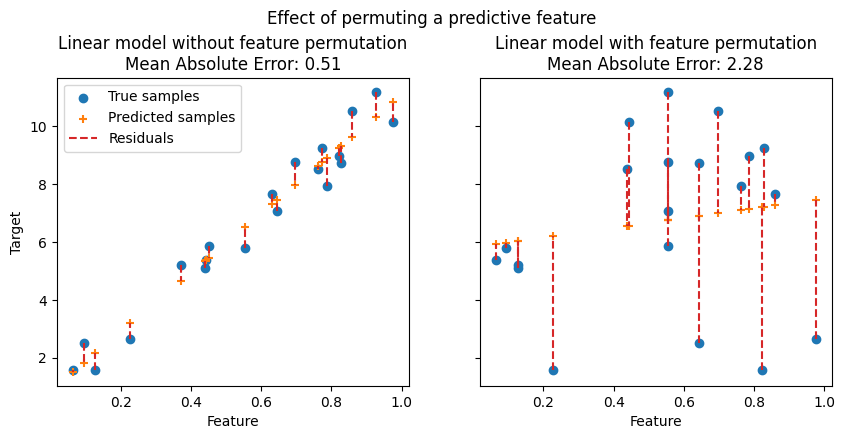

Source: https://scikit-learn.org/stable/modules/permutation_importance.html

---

- **Core Idea**: 
  - Measure how much the model’s prediction accuracy **drops** when the values of one feature are randomly **shuffled**.
  - This breaks the relationship between that feature and the target, simulating what the model would do **without that feature’s signal**.

- **Key Steps**:
  1. Compute model performance on the **original data** using a chosen metric (e.g., RMSE).
  2. For each feature:
     - Shuffle its values across observations (i.e., permute).
     - Measure the **new model performance** with this permuted feature.
     - Calculate the **difference in error** (e.g., `RMSE_permuted - RMSE_original`).
  3. Repeat this process multiple times to get stable estimates.

- **Interpretation**:
  - A **larger increase in error** after permutation = **higher importance**.
  - If permutation doesn’t change error much → the feature has **little to no impact** on the model.

- **Metric in regression**:
  - Use **negative RMSE** (`neg_root_mean_squared_error`) or **negative MSE** to align with scikit-learn's scoring.
  - Importance is reported as a **decrease in performance** after feature permutation.

  ---


#### **Sklearn-inspection**

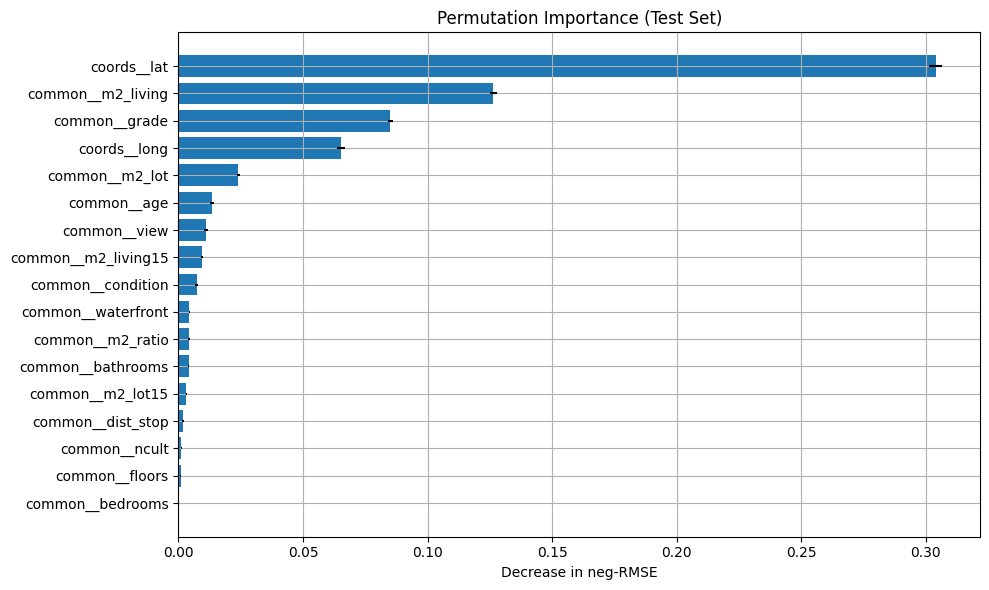

In [9]:
result_test = permutation_importance(
    models['XGB Coords'].named_steps['model'],
    X_test_transformed_coords,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=2,
    scoring="neg_root_mean_squared_error"
)

importance_test_df = pd.DataFrame({
    'feature': X_test_transformed_coords.columns,
    'importance_mean': result_test.importances_mean,
    'importance_std': result_test.importances_std
}).sort_values(by="importance_mean", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_test_df['feature'], importance_test_df['importance_mean'],
         xerr=importance_test_df['importance_std'], align='center')
plt.xlabel("Decrease in neg-RMSE")
plt.title("Permutation Importance (Test Set)")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


#### **Dalex version**


In [15]:
for name, explainer in dalex_explainers.items():
    print(f"{name}")
    explainer.model_parts().plot(title=f"Permutation Importance – {name}")


XGB Coords Log


XGB Coords


XGB District Log


XGB District


In [17]:
# Compute permutation-based variable importance
vi = dalex_explainers['XGB Coords Log'].model_parts()

# Sort by importance (drop in performance when permuted)
top_features = vi.result.sort_values(by="dropout_loss", ascending=False)

# Display top 10 features
top_features[["variable", "dropout_loss"]].head(20)


,variable,dropout_loss
18,_baseline_,0.710933
17,coords__lat,0.456597
16,common__m2_living,0.282778
15,common__grade,0.241873
14,coords__long,0.221160
13,common__m2_lot,0.180538
12,common__age,0.168927
11,common__view,0.167762
10,common__m2_living15,0.165972
9,common__condition,0.163442


In [18]:
top_features = top_features[~top_features['variable'].isin(['_baseline_', '_full_model_'])][:12]['variable'].tolist()
top_features

['coords__lat',
 'common__m2_living',
 'common__grade',
 'coords__long',
 'common__m2_lot',
 'common__age',
 'common__view',
 'common__m2_living15',
 'common__condition',
 'common__bathrooms',
 'common__m2_lot15',
 'common__m2_ratio']

## 🔍 **Partial Dependence Profiles**

---


- **Core Idea**  
  Show how the model’s **average prediction** responds when you vary one feature across its range, keeping all other features at their observed values.

- **How to Compute**  
  1. Pick a feature and a set of values to test.  
  2. For each value, replace that feature in **all** rows with the test value.  
  3. Run the model on these modified datasets and **average** the predictions.  
  4. Plot the average prediction against the feature values.

- **ICE Overlay**  
  Add **Individual Conditional Expectation** (ICE) lines—one per instance—to see how each observation’s prediction moves, revealing variation around the average trend.

- **When to Use**  
  - **Global effect**: understand a feature’s overall impact.  
  - **Subgroup analysis**: compare profiles for different groups (e.g. gender, region).  
  - **Model comparison**: highlight differences between simple (e.g. linear) and complex (e.g. tree-based) models.

- **Pros & Cons**  
  - Offers a clear global summary.  
  - Easy to compute for one feature.  
  - Assumes feature independence—can create unrealistic data if features are correlated.  
  - Averages can hide individual or subgroup differences (use ICE or subgroup plots to complement).

  ---


#### **PDP with sklearn-inspection**

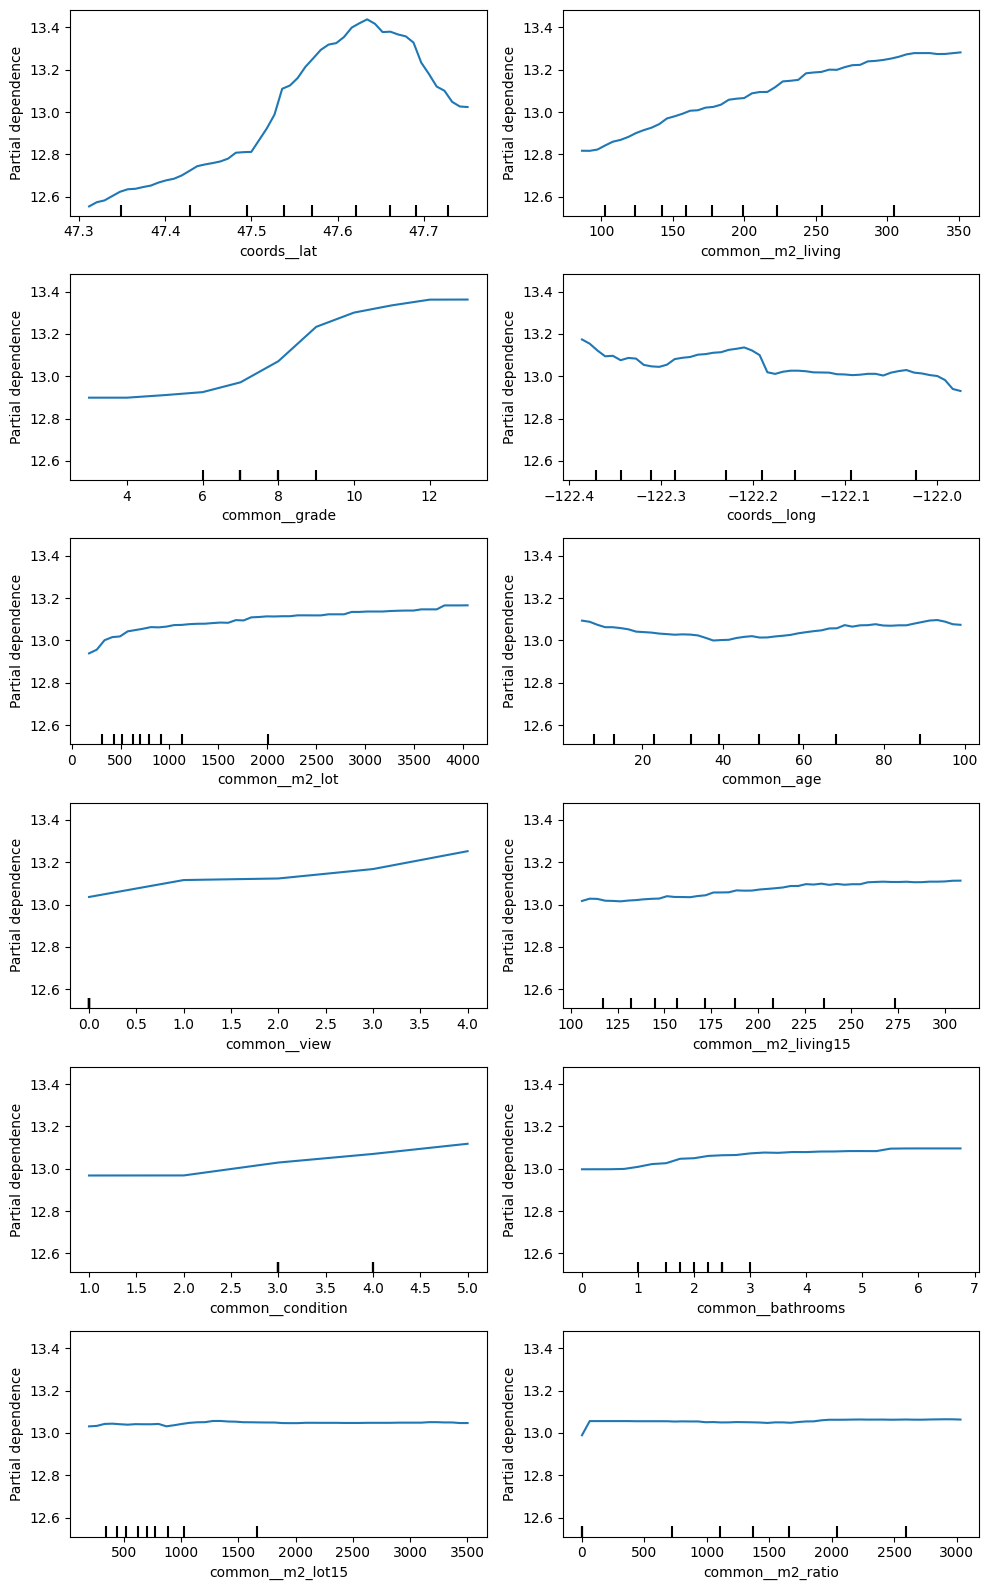

In [19]:
fig, ax = plt.subplots(6, 2, figsize=(10, 16)) 
ax = ax.ravel()  

PartialDependenceDisplay.from_estimator(
    models['XGB Coords'].named_steps['model'],
    X_test_transformed_coords,
    features=top_features,
    grid_resolution=50,
    random_state=0,
    kind='average',
    ax=ax, 
    # subsample=100
)

plt.tight_layout()
plt.show()

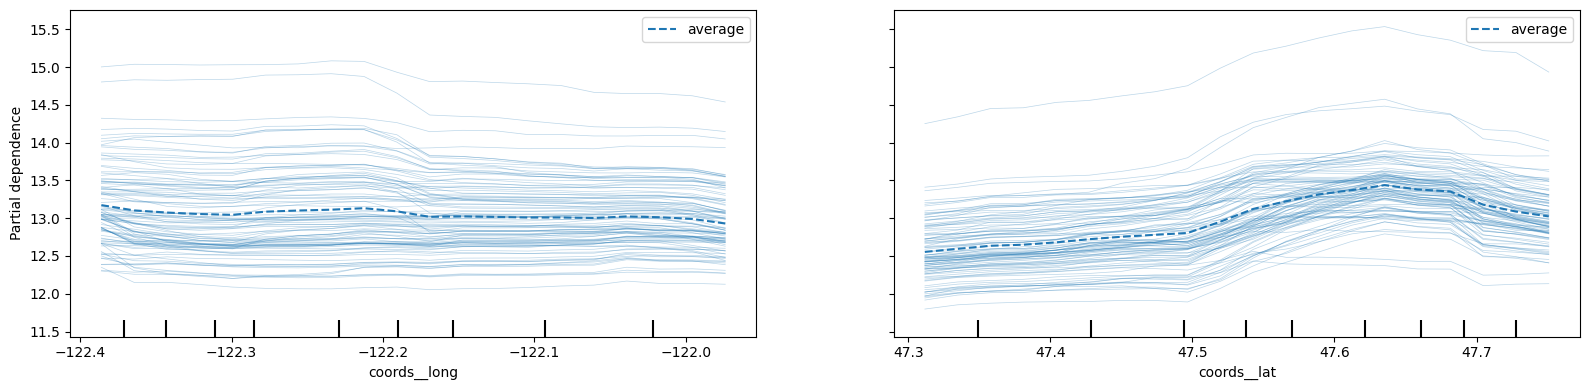

In [20]:
fig, ax = plt.subplots(figsize=(16, 4))

PartialDependenceDisplay.from_estimator(
    models['XGB Coords'].named_steps['model'],
    X_test_transformed_coords,
    kind="both",
    features=['coords__long', 'coords__lat'],
    grid_resolution=20,
    ax=ax, 
    subsample=100
)

plt.tight_layout()
plt.show()

#### **Dalex version**

In [21]:
pdp = dalex_explainers['XGB Coords Log'].model_profile(variables=top_features[:5], type="partial")
pdp.plot()


Calculating ceteris paribus: 100%|██████████| 5/5 [00:00<00:00, 19.56it/s]


In [22]:
pdp = dalex_explainers['XGB District'].model_profile(variables=['common__grade', 'common__age', 'district__district_name_Federal Way', 'district__district_name_Kent', 'district__district_name_King County'], type="partial")
pdp.plot()


Calculating ceteris paribus: 100%|██████████| 5/5 [00:00<00:00, 18.34it/s]


## 🔍 **Accumulated Local Effects**

- **Core Idea**:  
  - Estimate a feature’s effect on predictions by measuring **average local changes** when you nudge that feature within small intervals, while keeping all other features at their observed values.  
  - This “accumulated” approach avoids creating unrealistic data combinations and respects the true joint distribution of correlated inputs.

- **Key Steps**:  
  1. **Bin the feature’s range** into contiguous intervals.  
  2. For each interval:  
     - Identify all observations whose feature value lies in that bin.  
     - For each of those observations:  
       1. Predict with the feature set to the **upper bin boundary**.  
       2. Predict with the feature set to the **lower bin boundary**.  
       3. Compute the **difference** in predictions for that observation.  
     - **Average** these differences across all observations in the bin → this gives the **local effect** for that interval.  
  3. **Accumulate** the local effects from the lowest bin up to each bin to build the full ALE curve.  
  4. **Center** the curve by subtracting its mean so that the baseline (zero) represents no net effect.

- **Interpretation**:  
  - **Positive ALE** at a given feature value means increasing the feature in that region tends to **increase** the model’s prediction.  
  - **Negative ALE** means the feature tends to **decrease** predictions.  
  - **Flat segments** → little or no effect; **non-monotonic shapes**, **thresholds**, or **oscillations** reveal complex nonlinear behavior.

- **Advantages (vs PDP)**:  
  - **Respects feature correlation** by only perturbing within actual data neighborhoods.  
  - **Avoids bias** from unrealistic data combinations.  
  - **Efficient** and more reliable when features are strongly correlated.

- **Use in Regression**:  
  - ALE values are on the **same scale** as model predictions (e.g., target units).  
  - No additional scoring metric is needed—interpret the curve directly as **average change in prediction** per unit change in the feature.  


In [ ]:
# # Create the ALE explainer
top_features = ['coords__lat',
 'common__m2_living',
 'common__grade',
 'coords__long',
 'common__m2_lot',
 'common__age',
 'common__view',
 'common__m2_living15',
 'common__condition',
 'common__bathrooms',
 'common__m2_lot15',
 'common__m2_ratio']

ale = ALE(predictor=models['XGB Coords'].named_steps['model'].predict, feature_names=models['XGB Coords'].named_steps['preprocess'].get_feature_names_out())

# # Fit on the test set (or a representative sample)
ale_exp = ale.explain(X_test_transformed_coords.to_numpy())


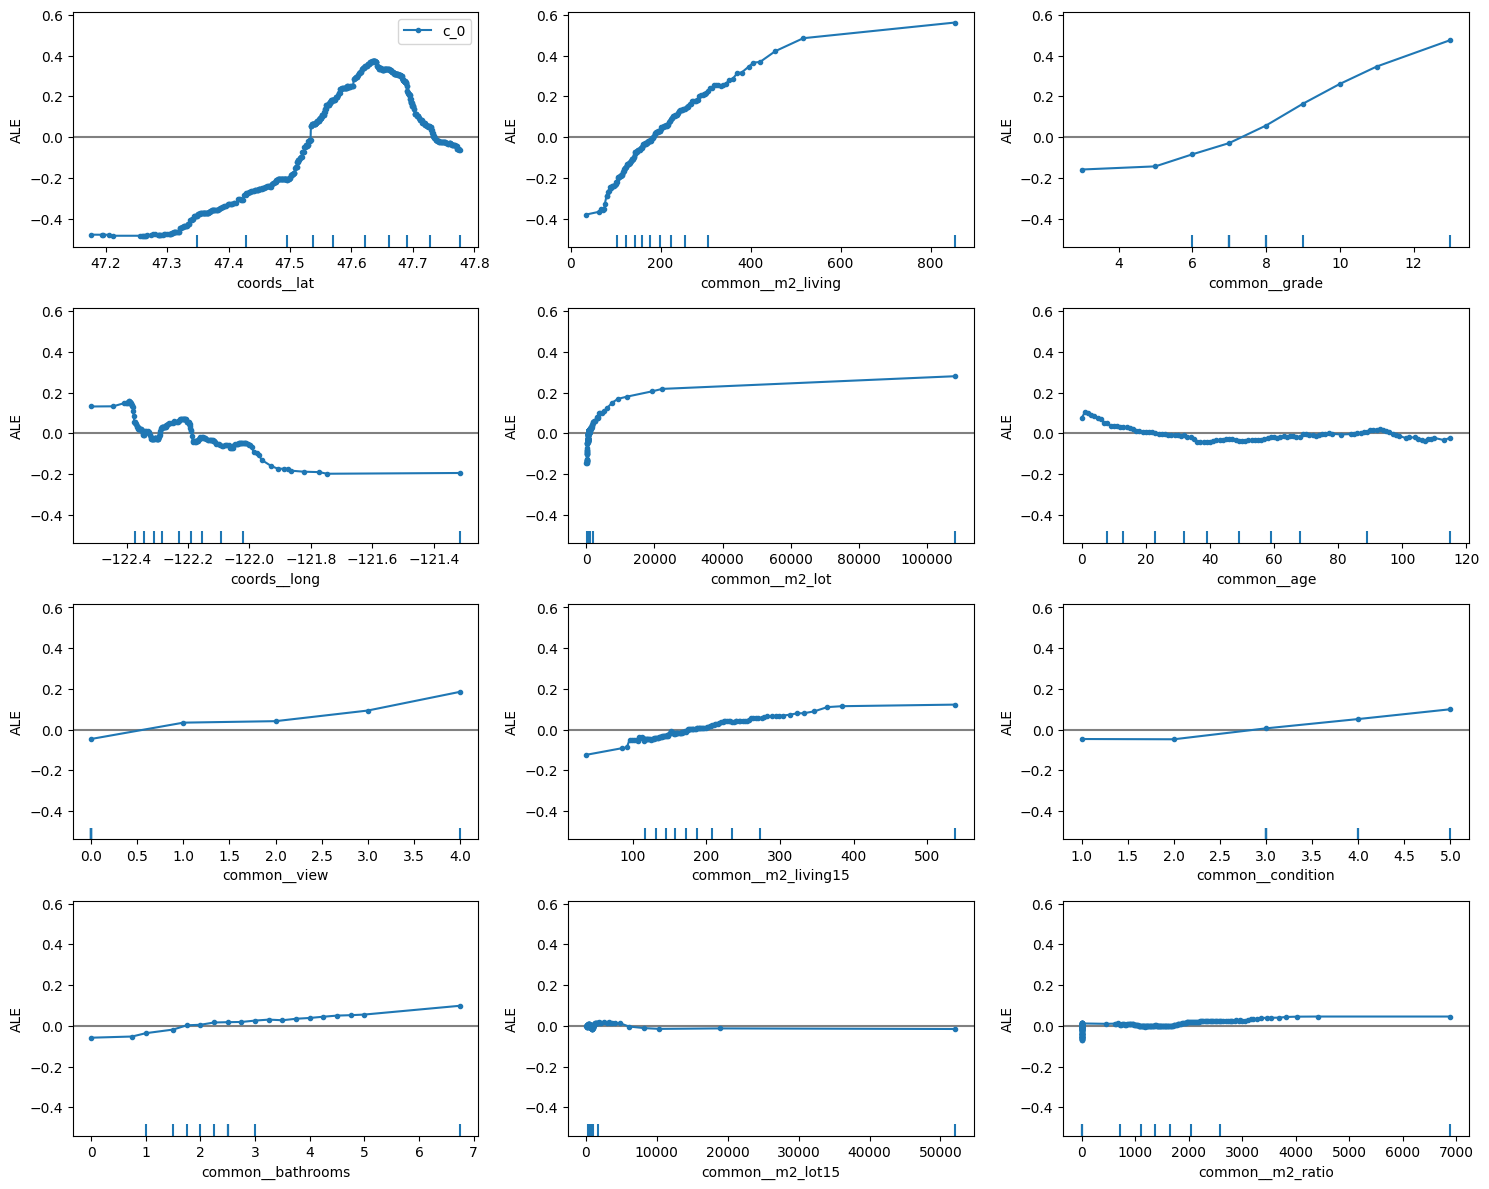

In [16]:
# Plot ALE explanation for first 3 features
plot_ale(ale_exp, features=top_features, fig_kw={'figwidth':15, 'figheight': 12})

plt.tight_layout()

Text(0.5, 0, 'weight')

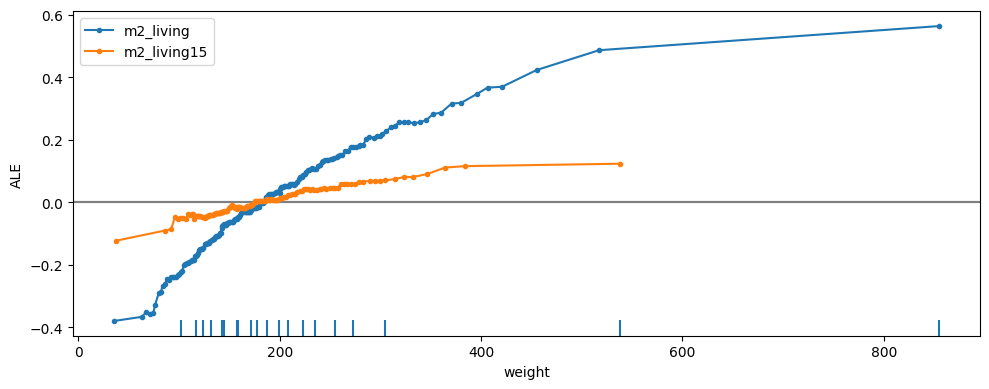

In [17]:
# Plot ALE for weight features
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

plot_ale(ale_exp, features=['common__m2_living'], ax=ax, line_kw={'label': 'm2_living'})
plot_ale(ale_exp, features=['common__m2_living15'], ax=ax, line_kw={'label': 'm2_living15'})

ax.set_xlabel('weight')

## 🔍 **Shapley Additive Exaplanations**

---

- **Core Idea**  
  - Fairly distribute a model's prediction among all input features by attributing to each feature its **average marginal contribution** across all possible feature combinations.  
  - Based on **Shapley values** from cooperative game theory.

- **Key Steps**  
  1. Consider the model’s prediction for a single instance \( x \).  
  2. For each feature:  
     - Evaluate the prediction difference when the feature is **added to a subset** of other features.  
     - Compute the **marginal contribution** of the feature in that context.  
  3. Average the feature’s marginal contributions over **all possible subsets** of features.  
  4. The result is the **Shapley value** for that feature — its share of the prediction.

- **Interpretation**  
  - **Positive value** → the feature **increases** the prediction relative to the average.  
  - **Negative value** → the feature **decreases** the prediction.  
  - The **sum of all Shapley values** + the **expected model output** equals the model's prediction.


- **Limitations**  
  -  **Computationally expensive** for many features (approximations used in practice).  
  -  May be **hard to interpret** if features are highly correlated (can lead to attribution ambiguity).  

  ---


In [23]:
shap_explainers = {}
shap_values = {}

for name, model in models.items():

    # Transform the data
    X_test_transformed = pd.DataFrame(
        model.named_steps['preprocess'].transform(X_test),
        columns=model.named_steps['preprocess'].get_feature_names_out()
    )

    # Create SHAP explainer (use TreeExplainer for tree models)
    shap_explainer = shap.Explainer(model.named_steps['model'])
    shap_value = shap_explainer(X_test_transformed)

    # Save
    shap_explainers[name] = shap_explainer
    shap_values[name] = shap_value


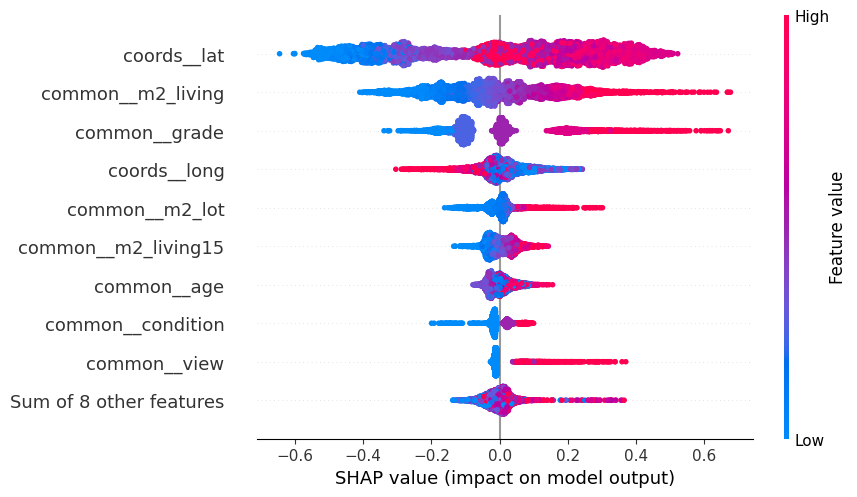

In [24]:
shap.plots.beeswarm(shap_values['XGB Coords'])
# shap.plots.beeswarm(shap_values['XGB District'])

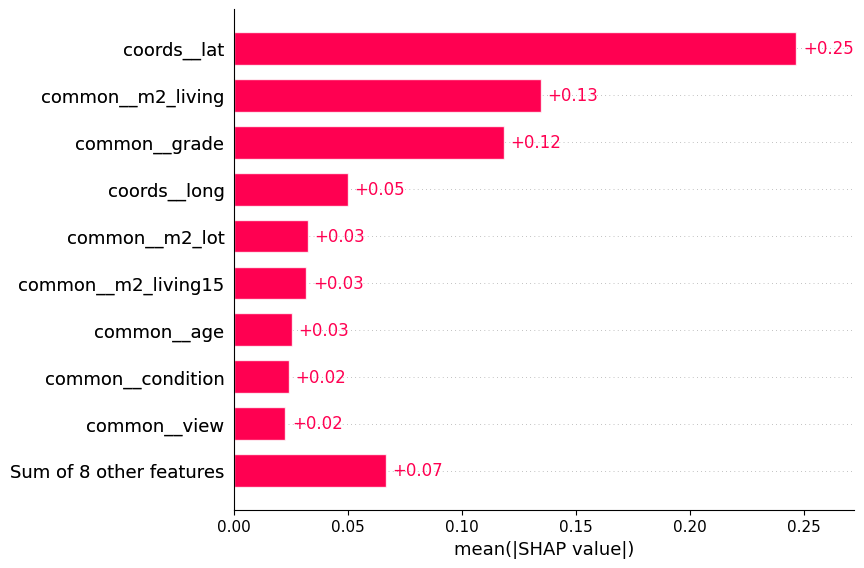

In [25]:
shap.plots.bar(shap_values['XGB Coords'])

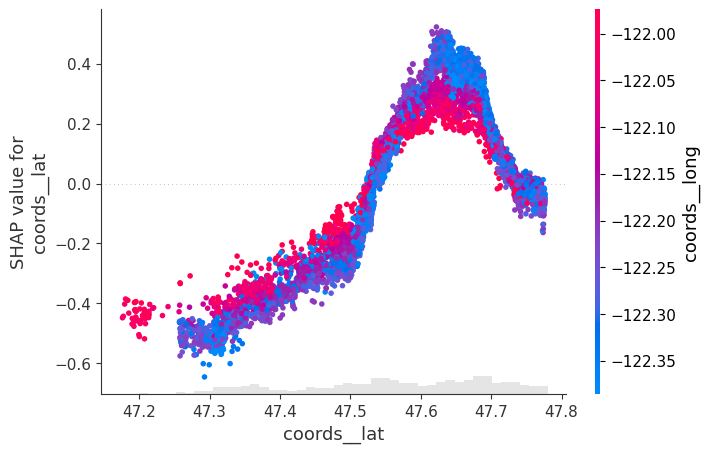

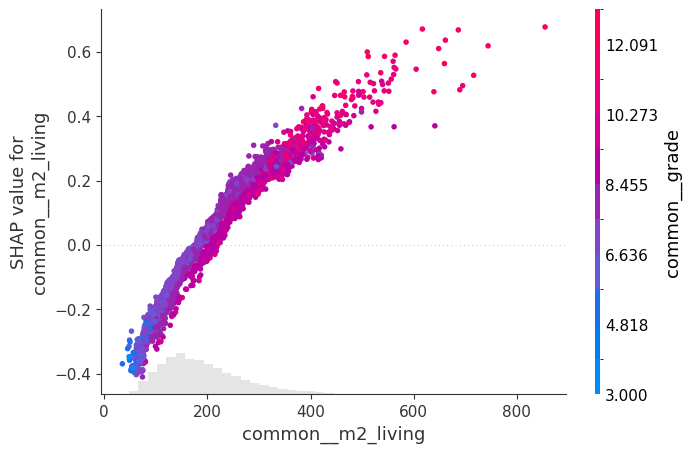

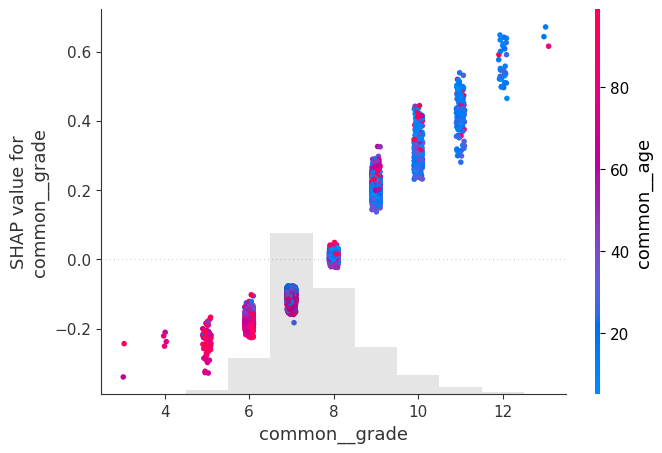

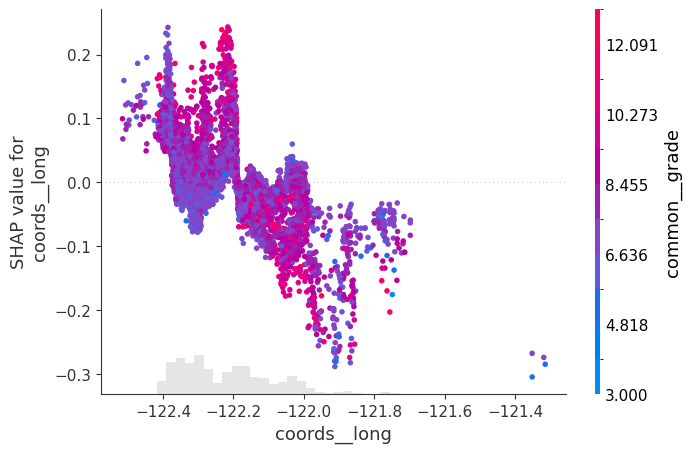

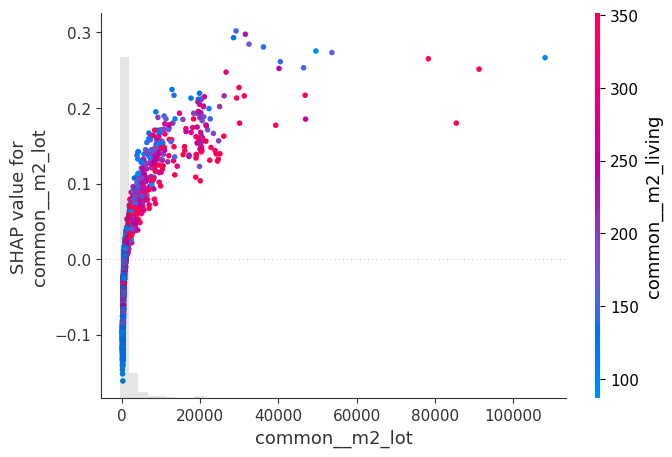

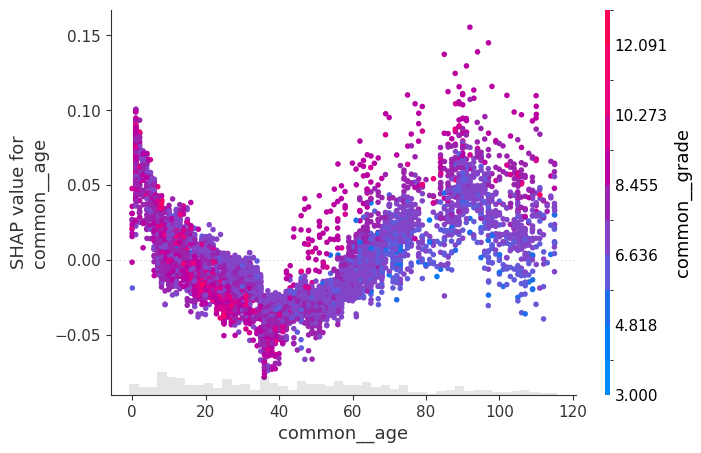

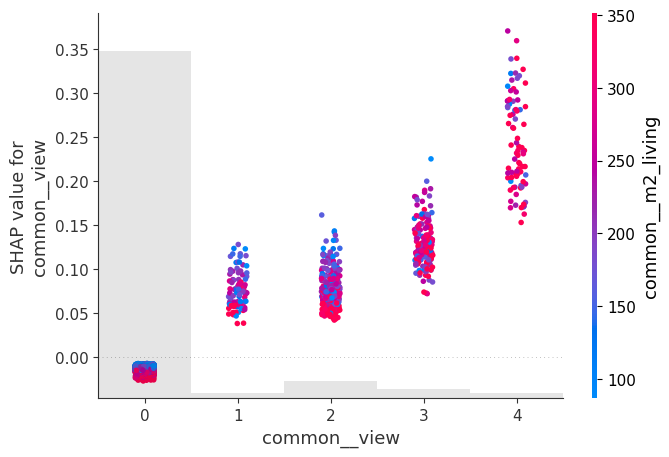

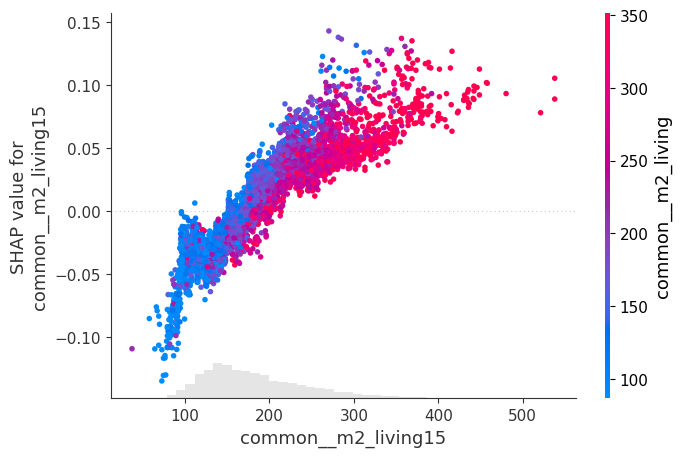

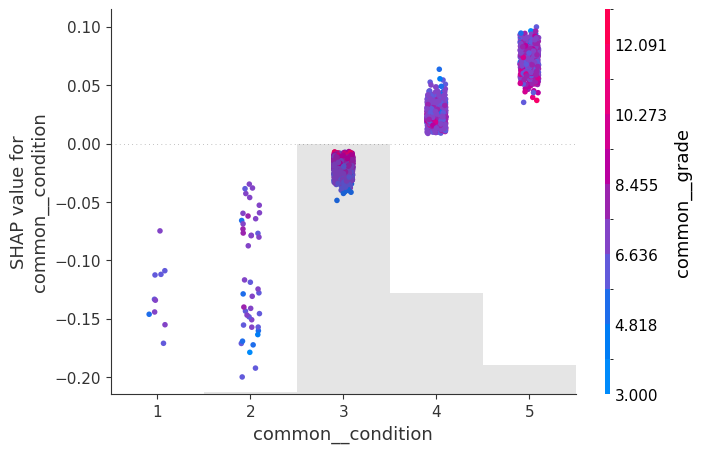

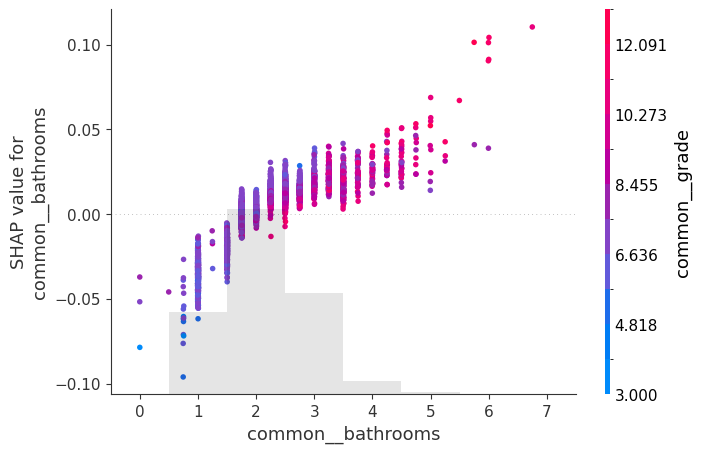

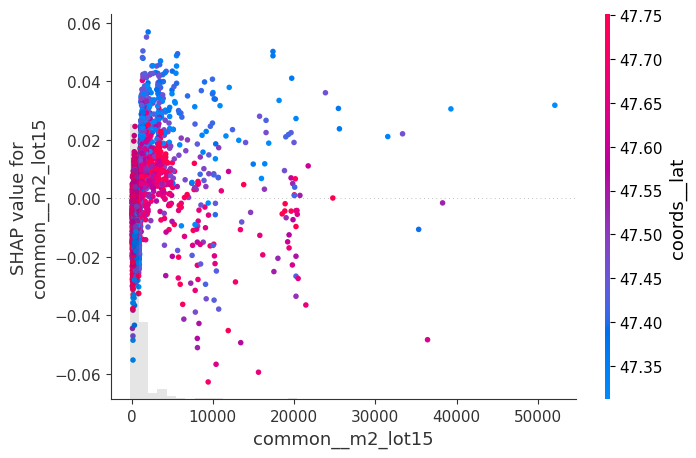

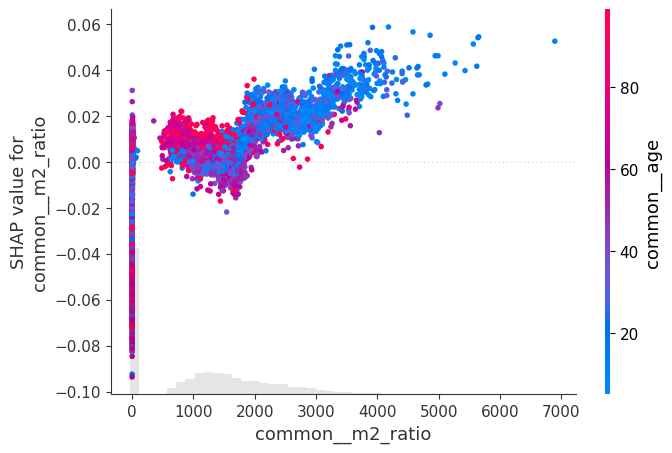

In [26]:
for i in top_features:
    shap.plots.scatter(shap_values['XGB Coords'][:, i], color=shap_values['XGB Coords'])

## 🔍 **The Break Down Method**

- **Core Idea**  
  Break Down explains a single prediction by showing how much each feature contributes to the difference between the model’s average prediction and the actual prediction for a given instance.

- **How It Works**  
  - Start from the model’s average prediction.  
  - Add features one-by-one in a chosen order.  
  - At each step, measure how the prediction changes when a new feature is added.  
  - The change is assigned as that feature’s contribution.

- **Key Characteristics**  
  - The **sum of all contributions** plus the average prediction equals the final prediction.  
  - **Order matters**: for non-additive models, results depend on the order in which features are added.  
  - **Additive models** are stable regardless of order.



In [30]:
X_test_transformed_district.iloc[138]

district__district_name_Federal Way         0.000000
district__district_name_Kent                0.000000
district__district_name_King County         1.000000
district__district_name_Kirkland            0.000000
district__district_name_Mercer Island       0.000000
district__district_name_Renton              0.000000
district__district_name_Sammamish           0.000000
district__district_name_Seattle             0.000000
district__district_name_Shoreline           0.000000
common__bathrooms                           2.750000
common__bedrooms                            5.000000
common__floors                              1.000000
common__waterfront                          0.000000
common__view                                0.000000
common__condition                           4.000000
common__grade                               7.000000
common__dist_stop                         190.000000
common__ncult                               0.000000
common__age                                52.

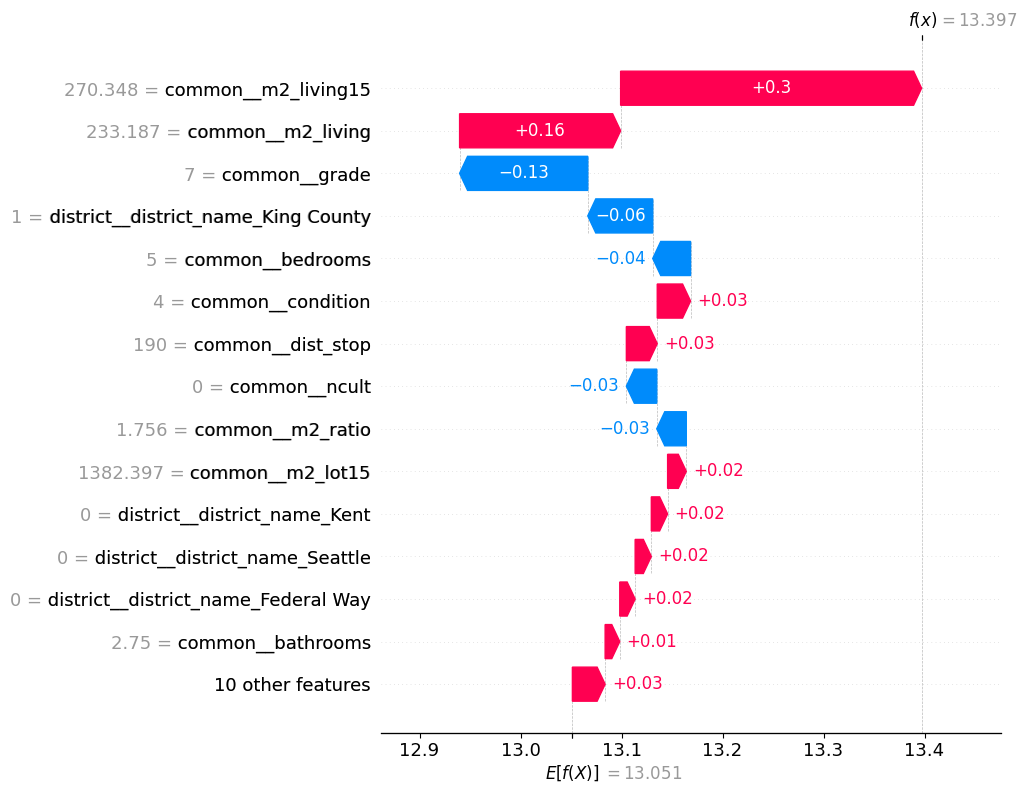

In [31]:
shap.plots.waterfall(shap_values['XGB District'][138], max_display=15)

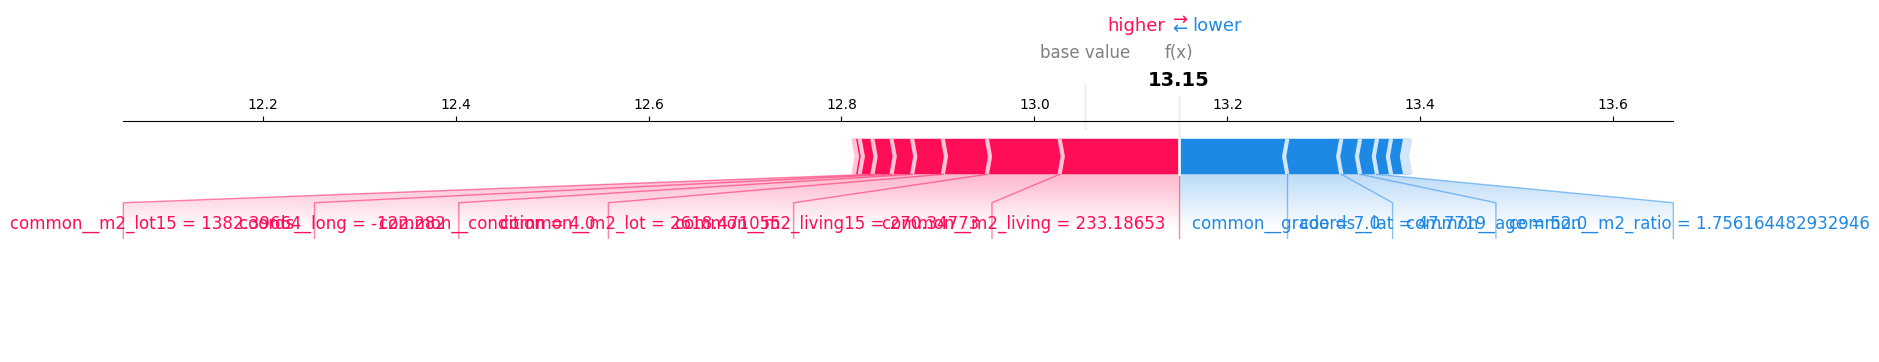

In [32]:
shap.plots.force(
            shap_values['XGB Coords'][138],
            matplotlib=True,
            show=False
        )

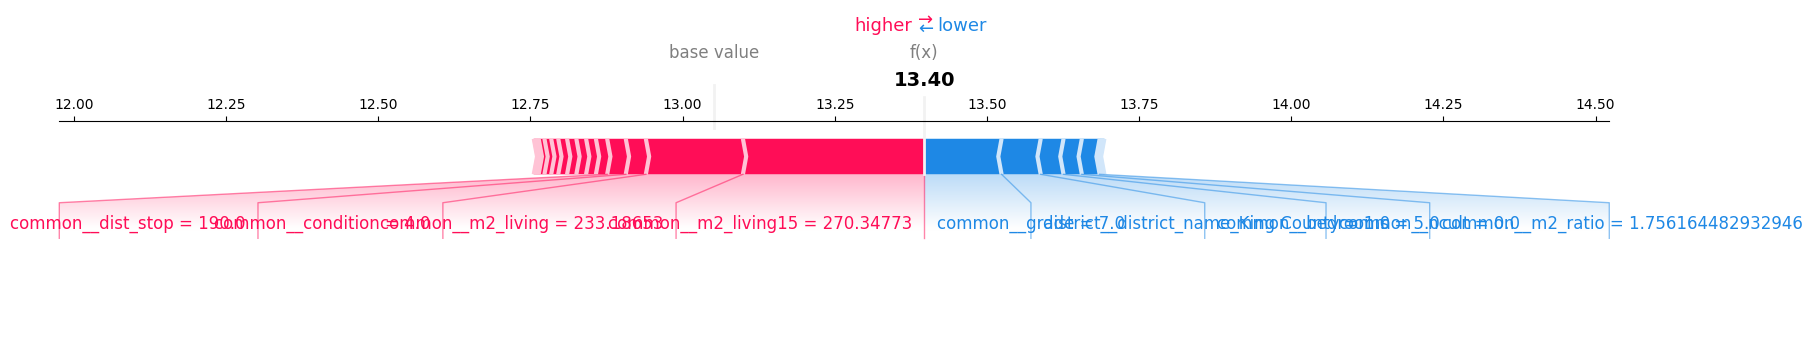

In [33]:
shap.plots.force(
            shap_values['XGB District'][138],
            matplotlib=True,
            show=False
        )

#### **DALEX version - break down**

In [34]:
dalex_explainers['XGB District Log'].predict_parts(X_test_transformed_district.iloc[[138]], type = "break_down").plot()

## 🔍 **LIME - Local Interpretable Model-agnostic Explanations**


The **LIME method** (Local Interpretable Model-agnostic Explanations), introduced by **Marco Ribeiro et al. (2016)**, aims to interpret complex models by **locally approximating them with simpler, interpretable models**.

---
Key Idea:

LIME treats the black-box model as a function that can be locally approximated by a simple, interpretable model — usually a **linear regression** — around a specific prediction.

- Select a point of interest \( x_+ \) (a single test instance).
- Generate **perturbed samples** (new, similar observations) around \( x_+ \).
- Use the black-box model (e.g., XGBoost, Random Forest) to predict these new points.
- Fit a **weighted linear regression** to the perturbed data:
  - Weight points by **how close they are to \( x_+ \)** (closer = more weight).
  - The linear model approximates the black-box model **only around \( x_+ \)**.

**Interpretation**:
- The coefficients of the linear model tell you **how each feature influences the prediction at \( x_+ \)**.
- These coefficients are **local explanations** — they may not generalize beyond the neighborhood of the selected point.
- The explanation answers: *“Which features pushed this prediction up or down?”*

**Special case for regression**:

Unlike classification, where probabilities are explained, in regression LIME explains **the predicted numeric value** directly.  
You can easily quantify **how much** each feature increases or decreases the prediction in local terms.

---



In [36]:
from IPython.display import display, HTML


lime_explainer = LimeTabularExplainer(
    training_data=X_test_transformed_coords.values,
    feature_names=X_test_transformed_coords.columns.tolist(),
    mode='regression'
)

exp = lime_explainer.explain_instance(
    data_row=X_test_transformed_coords.iloc[138].values,
    predict_fn=models['XGB Coords'].named_steps['model'].predict
)

display(HTML(exp.as_html())) 


## 📚 **Supplementary references**

- **Accumulated Local Effects (ALE)**  
  Apley and Zhu (2016): 
  
  [https://arxiv.org/abs/1612.08468](https://arxiv.org/abs/1612.08468)




- **Partial Dependence**  
  Friedman (2001): 
  
  [https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boostingmachine/10.1214/aos/1013203451.full](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boostingmachine/10.1214/aos/1013203451.full)



- **Partial Dependence Variance**  
  Greenwell et al. (2018): 
  
  [https://arxiv.org/abs/1805.04755](https://arxiv.org/abs/1805.04755)

- **Permutation Importance**  
  Breiman (2001): 
  
  [https://link.springer.com/article/10.1023/A:1010933404324](https://link.springer.com/article/10.1023/A:1010933404324)  
  
  Fisher et al. (2018): 
  
  [https://arxiv.org/abs/1801.01489](https://arxiv.org/abs/1801.01489)

- **Anchor Explanations**  
  Ribeiro et al. (2018): 
  
  [https://homes.cs.washington.edu/~marcotcr/aaai18.pdf](https://homes.cs.washington.edu/~marcotcr/aaai18.pdf)


- **Counterfactual Explanations**  
  Wachter et al. (2017): 
  
  [https://arxiv.org/abs/1711.00399](https://arxiv.org/abs/1711.00399)

- **Counterfactual Explanations Guided by Prototypes**  
  Van Looveren and Klaise (2019): 
  
  [https://arxiv.org/abs/1907.02584](https://arxiv.org/abs/1907.02584)


- **Kernel SHAP (Shapley Additive Explanations)**  
  Lundberg et al. (2017): 
  
  [https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions](https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions)

- **Tree Shapley Additive Explanations** 
([Lundberg et al., 2020](https://www.nature.com/articles/s42256-019-0138-9))
